# Global-co-emissions and other factors


Global emissions has risen - it is impacting the environment [1]. Demography and GDP may be factors to increase carbon dioxide emissions [2,3]. The latter has been discussed in the last two decades and various analytical model created. We use various data made available on Kaggle to explore those factors. We aim to answer the following questions: 


- Is there a trend of emissions throug time?
- Has the GDP changed through time?



__References:__ 
1. Töbelmann, Daniel, and Tobias Wendler. "The impact of environmental innovation on carbon dioxide emissions." Journal of Cleaner Production 244 (2020): 118787
2. O'Neill, Brian C., et al. "Demographic change and carbon dioxide emissions." The Lancet 380.9837 (2012): 157-164.
3. Tucker, Michael. "Carbon dioxide emissions and global GDP." Ecological Economics 15.3 (1995): 215-223.

## Upload libraries and data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.mixture import GaussianMixture as GMM

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/air-quality-per-country-with-gdp-and-population/air_gdp_density.csv
/kaggle/input/2023-world-population-by-country/countries-table.csv
/kaggle/input/2023-world-population-by-country/countries-table.json
/kaggle/input/gdp-growth-around-the-globe/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/gdp-growth-around-the-globe/Metadata_Indicator_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/gdp-growth-around-the-globe/Metadata_Country_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/global-co-emissions/GlobalCO2Emissions.csv
/kaggle/input/countries-gdp-19602020/Countries GDP 1960-2020.csv
/kaggle/input/world-population-dataset/world_population.csv
/kaggle/input/countries-of-the-world-2023/world-data-2023.csv
/kaggle/input/co2-emissions-by-country/co2_emissions_kt_by_country.csv
/kaggle/input/countries-gdp-2012-to-2021/GDP.csv


In [2]:
d = pd.read_csv('/kaggle/input/global-co-emissions/GlobalCO2Emissions.csv')

d.dtypes

Year           int64
Emissions    float64
dtype: object

In [3]:
d.head()

,Year,Emissions
0,1750,0.03
1,1760,0.03
2,1770,0.03
3,1780,0.03
4,1790,0.04


## Data exploration

The dataset has two statistical variables - year and emissions. The observations appears to have occurred between 1750 and 2023. The  emissions appears range from extremely low values to high ones. However, most occurences appear to be low. 

In [4]:
d.describe()

,Year,Emissions
count,29.000000,29.000000
mean,1889.827586,5.937586
std,84.855368,11.443084
min,1750.000000,0.030000
25%,1820.000000,0.060000
50%,1890.000000,0.430000
75%,1960.000000,3.740000
max,2023.000000,40.900000


array([[<Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Emissions'}>]], dtype=object)

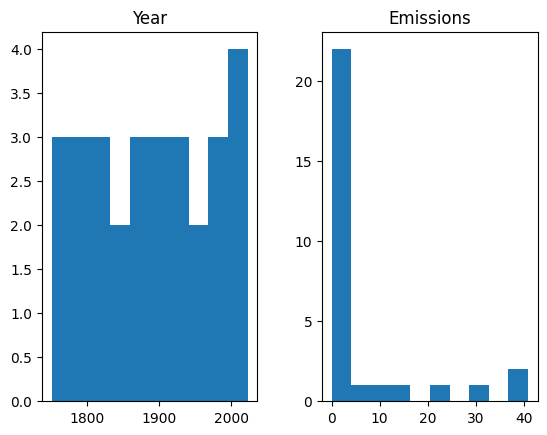

In [5]:
d.hist(grid = False)

## Is there a trends of emissions produced through time?

<Axes: xlabel='Year', ylabel='Emissions'>

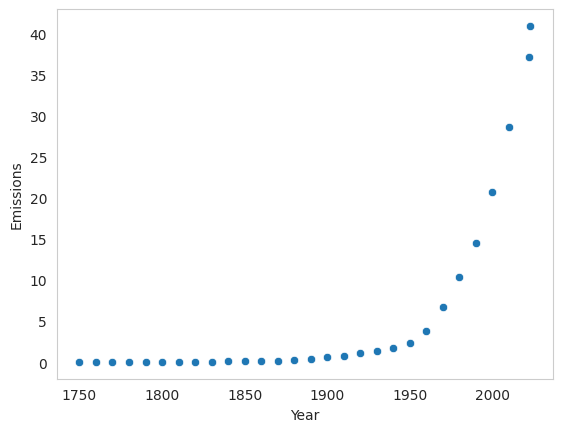

In [6]:
import seaborn as sns
sns.set_style("whitegrid", {'axes.grid' : False})
sns.scatterplot(x='Year', y='Emissions', data=d)

We model the relationship using the exponential equation and predict the observations to check accuracy.

For fitting an exponential equation (equation 1.0), we take the logarithm of both side to fit log of y against x. (see equation 2.0). Fitting _log(y)_  -  as if it is linear - emphasizes small values of _y_, causing large deviation for large value of _y_. A linear regression seeks finding a gradient ($\delta y$) that minimises the distance between the predicted and known values of _y_ (see equation 3.0). We assume  $Y_i = \log y_i$. We also assume an approximation of the $\Delta Y_i$ is the difference betweeh _y_ and its absolute values, causing favouring small values (see equation 4.0). For that reason, the reduce large values with a square root. 

$y = Ae^{Bx}$ (1.0)

$log y  = log (A + Bx)$ (2.0) 

$\sum_{i} \Delta y{2} = \sum{i} \left(y_{i} -\hat{y_{i}} \right)^2$ (3.0)

$\Delta Y_i = \Delta (\log y_i) ≈ \Delta y_i / |y_i|$  (4.0)


We use two models one with the reduction of values of _y_ and without.


In [7]:
fit = np.polyfit(d['Year'], np.log(d['Emissions']), 1)

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.02869030176345192
Coefficient B =  -54.781444681281656


count    29.000000
mean      1.958857
std       3.997135
min       0.003330
25%       0.019677
50%       0.150126
75%       0.864781
max      14.875568
Name: errors_model_A, dtype: float64

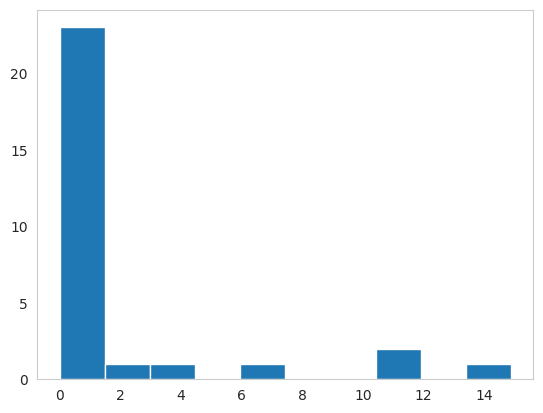

In [8]:
d['model_A'] = np.exp(fit[1]) * np.exp(fit[0] * d['Year']) 
d['errors_model_A']  = np.abs(d['Emissions'] - d['model_A'])
d.errors_model_A.hist(grid = False)
d.errors_model_A.describe()

This could be alleviated by giving each entry a "weight" proportional to y. polyfit supports weighted-least-squares via the w keyword argument.

In [9]:
np.sqrt(d.Emissions).describe()

count    29.000000
mean      1.555659
std       1.908700
min       0.173205
25%       0.244949
50%       0.655744
75%       1.933908
max       6.395311
Name: Emissions, dtype: float64

In [10]:
fit = np.polyfit(d['Year'], np.log(d['Emissions']), 1, w = np.sqrt(d.Emissions))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.03430748369375951
Coefficient B =  -65.67787308498968


count    29.000000
mean      0.449098
std       0.745753
min       0.000193
25%       0.020054
50%       0.026446
75%       0.697636
max       2.969357
Name: errors_model_B, dtype: float64

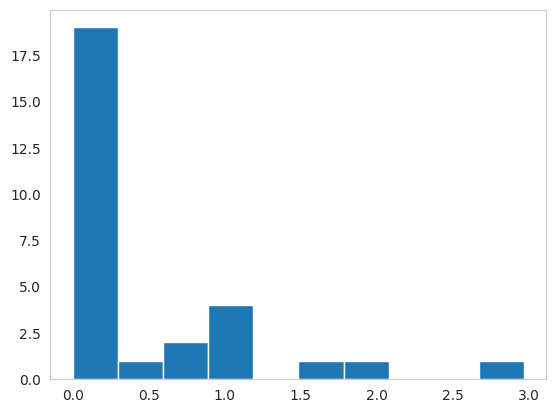

In [11]:
d['model_B'] = np.exp(fit[1]) * np.exp(fit[0] * d['Year']) 
d['errors_model_B']  = np.abs(d['Emissions'] - d['model_B'])
d.errors_model_B.hist(grid=False)
d.errors_model_B.describe()

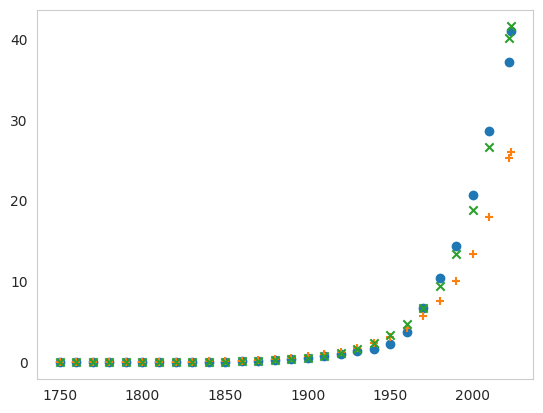

In [12]:
import matplotlib.pyplot as plt

plt.scatter(x=d['Year'], y= d['Emissions'])
plt.scatter(x=d['Year'], y= d['model_A'], marker = "+")
plt.scatter(x=d['Year'], y= d['model_B'], marker = "x")



Accuracy of Model A:

In [13]:
from sklearn.metrics import mean_absolute_error
print("MAE",mean_absolute_error(d['Emissions'],d['model_A']))


from sklearn.metrics import r2_score
r2 = r2_score(d['Emissions'], d['model_A'])
print('R2 ' , r2)
k=2
n = d.shape[0]
adj_r2_score = 1 - ((1-r2)*(n-1)/(n-k-1))
print('Adj R2 score ' ,adj_r2_score)


MAE 1.9588565646273792
R2  0.8476354892671631
Adj R2 score  0.8359151422877141


Accuracy of model B

In [14]:
from sklearn.metrics import mean_absolute_error
print("MAE",mean_absolute_error(d['Emissions'],d['model_B']))


from sklearn.metrics import r2_score
r2 = r2_score(d['Emissions'], d['model_B'])
print('R2 ' , r2)
k=2
n = d.shape[0]
adj_r2_score = 1 - ((1-r2)*(n-1)/(n-k-1))
print('Adj R2 score ' ,adj_r2_score)


MAE 0.44909784325335167
R2  0.9941575105083272
Adj R2 score  0.993708088239737


We have demonstrated that exponential relationship may exists in yearly carbon dioxide measurements through time. The relationship shows it is likely the carbon dioxide emissions should increase even more rapidly.

# Has the GDP changed through time?

We model the relationship using the exponential equation and predict the observations to check accuracy.

For fitting an exponential equation (equation 1.0), we take the logarithm of both side to fit log of y against x. (see equation 2.0). Fitting _log(y)_  -  as if it is linear - emphasizes small values of _y_, causing large deviation for large value of _y_. A linear regression seeks finding a gradient ($\delta y$) that minimises the distance between the predicted and known values of _y_ (see equation 3.0). We assume  $Y_i = \log y_i$. We also assume an approximation of the $\Delta Y_i$ is the difference betweeh _y_ and its absolute values, causing favouring small values (see equation 4.0). For that reason, the reduce large values with a square root. 

$y = Ae^{Bx}$ (1.0)

$log y  = log (A + Bx)$ (2.0) 

$\sum_{i} \Delta y{2} = \sum{i} \left(y_{i} -\hat{y_{i}} \right)^2$ (3.0)

$\Delta Y_i = \Delta (\log y_i) ≈ \Delta y_i / |y_i|$  (4.0)



In [15]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/air-quality-per-country-with-gdp-and-population/air_gdp_density.csv
/kaggle/input/2023-world-population-by-country/countries-table.csv
/kaggle/input/2023-world-population-by-country/countries-table.json
/kaggle/input/gdp-growth-around-the-globe/API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/gdp-growth-around-the-globe/Metadata_Indicator_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/gdp-growth-around-the-globe/Metadata_Country_API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_4701072.csv
/kaggle/input/global-co-emissions/GlobalCO2Emissions.csv
/kaggle/input/countries-gdp-19602020/Countries GDP 1960-2020.csv
/kaggle/input/world-population-dataset/world_population.csv
/kaggle/input/countries-of-the-world-2023/world-data-2023.csv
/kaggle/input/co2-emissions-by-country/co2_emissions_kt_by_country.csv
/kaggle/input/countries-gdp-2012-to-2021/GDP.csv


In [16]:
gdp = pd.read_csv('/kaggle/input/countries-gdp-19602020/Countries GDP 1960-2020.csv')
gdp.dtypes

Country Name     object
Country Code     object
1960            float64
1961            float64
1962            float64
                 ...   
2016            float64
2017            float64
2018            float64
2019            float64
2020            float64
Length: 63, dtype: object

In [17]:
value_vars = [ str(year) for year in range(1960, 2021)]
value_vars

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2018',
 '2019',
 '2020']

In [18]:

gdp_long = gdp.melt(id_vars='Country Code', value_vars = value_vars)
gdp_long['log_10_value'] = np.log10(gdp_long['value'])
gdp_long['variable'] = gdp_long['variable'].astype(int)
gdp_long.dtypes

Country Code     object
variable          int64
value           float64
log_10_value    float64
dtype: object

In [19]:
gdp_long.head()

,Country Code,variable,value,log_10_value
0,AFE,1960,1.931311e+10,10.285852
1,AFW,1960,1.040428e+10,10.017212
2,AUS,1960,1.860679e+10,10.269671
3,AUT,1960,6.592694e+09,9.819063
4,BDI,1960,1.960000e+08,8.292256


The yearly distributions appears to vary greatly, but the point of centrality appears to increase through time. The quartile of the log values appears to grow linear, which suggest an exponential relationship.  The errors distributions is skewed to the left and near 0, suggesting the model fitting process was quite accurate.  

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
count,1.190000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,...,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02,1.200000e+02
mean,7.737603e+10,7.918769e+10,8.417576e+10,9.092311e+10,9.976049e+10,1.091809e+11,1.177544e+11,1.244980e+11,1.338719e+11,1.480550e+11,...,4.266303e+12,4.403837e+12,4.564958e+12,4.711580e+12,4.499309e+12,4.564773e+12,4.886253e+12,5.207231e+12,5.303437e+12,5.146832e+12
std,2.252438e+11,2.335094e+11,2.507523e+11,2.696523e+11,2.944479e+11,3.211343e+11,3.498230e+11,3.731073e+11,4.036768e+11,4.443198e+11,...,1.111174e+13,1.135331e+13,1.167128e+13,1.199261e+13,1.139102e+13,1.158322e+13,1.231733e+13,1.311345e+13,1.332070e+13,1.292930e+13
min,1.201201e+07,1.159201e+07,1.254156e+07,1.283323e+07,1.341655e+07,1.359393e+07,1.446908e+07,1.583518e+07,1.460000e+07,1.585000e+07,...,6.761296e+08,6.929333e+08,7.212074e+08,7.277148e+08,7.554000e+08,7.744296e+08,7.921778e+08,8.113000e+08,8.250407e+08,8.074741e+08
25%,4.362676e+08,4.747200e+08,4.716388e+08,5.081636e+08,5.418066e+08,6.561320e+08,6.940201e+08,7.417202e+08,7.688965e+08,7.862815e+08,...,1.775774e+10,1.768566e+10,1.878204e+10,1.958781e+10,1.941603e+10,2.070647e+10,2.203821e+10,2.353911e+10,2.328174e+10,2.052449e+10
50%,2.723593e+09,2.667191e+09,3.050546e+09,3.570681e+09,3.184116e+09,3.590080e+09,4.230784e+09,4.194304e+09,4.571298e+09,5.726672e+09,...,2.365000e+11,2.250000e+11,2.345000e+11,2.395000e+11,2.165000e+11,2.310000e+11,2.525000e+11,2.750000e+11,2.740000e+11,2.580000e+11
75%,2.926200e+10,3.041073e+10,3.294838e+10,3.774822e+10,3.686680e+10,4.106156e+10,4.430473e+10,4.379965e+10,4.683330e+10,5.355294e+10,...,1.610000e+12,1.680000e+12,1.790000e+12,1.850000e+12,1.680000e+12,1.560000e+12,1.670000e+12,1.750000e+12,1.800000e+12,1.702500e+12
max,1.390000e+12,1.440000e+12,1.550000e+12,1.670000e+12,1.820000e+12,1.990000e+12,2.160000e+12,2.290000e+12,2.480000e+12,2.730000e+12,...,7.370000e+13,7.530000e+13,7.740000e+13,7.960000e+13,7.510000e+13,7.630000e+13,8.120000e+13,8.630000e+13,8.760000e+13,8.470000e+13


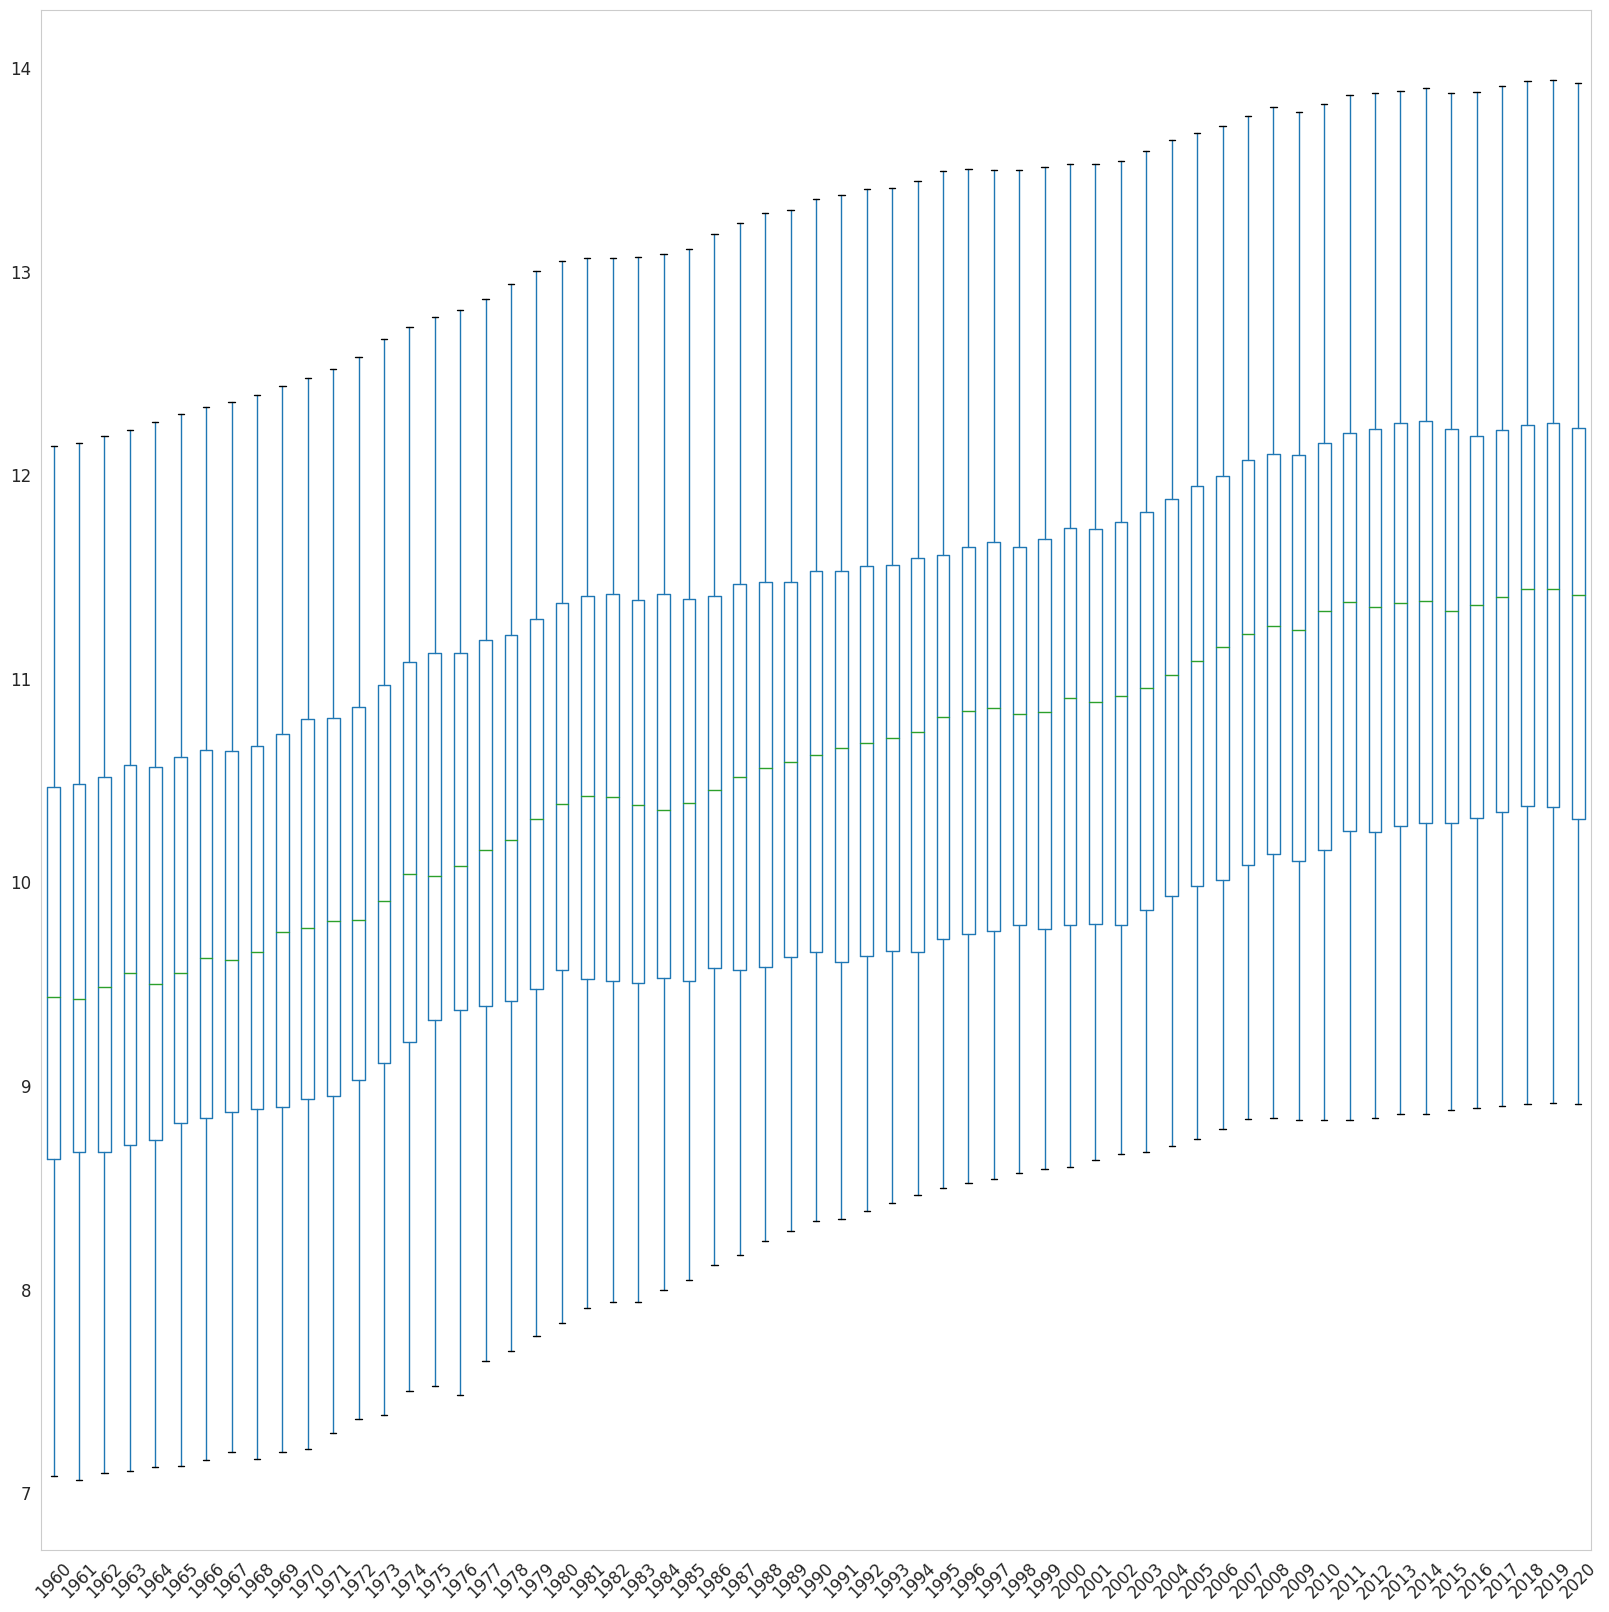

In [20]:
temp  = np.log10(gdp.loc[:, value_vars])
temp.boxplot(rot=45, fontsize = 12, grid = False, figsize=[20,20])
gdp.describe()

In [21]:
col  = ['variable', 'value']
temp = gdp_long.loc[:,col] 
stats = temp.groupby(['variable']).describe().droplevel(axis =1 , level= 0).reset_index()
stats

,variable,count,mean,std,min,25%,50%,75%,max
0,1960,119.0,7.737603e+10,2.252438e+11,1.201201e+07,4.362676e+08,2.723593e+09,2.926200e+10,1.390000e+12
1,1961,120.0,7.918769e+10,2.335094e+11,1.159201e+07,4.747200e+08,2.667191e+09,3.041073e+10,1.440000e+12
2,1962,120.0,8.417576e+10,2.507523e+11,1.254156e+07,4.716388e+08,3.050546e+09,3.294838e+10,1.550000e+12
3,1963,120.0,9.092311e+10,2.696523e+11,1.283323e+07,5.081636e+08,3.570681e+09,3.774822e+10,1.670000e+12
4,1964,120.0,9.976049e+10,2.944479e+11,1.341655e+07,5.418066e+08,3.184116e+09,3.686680e+10,1.820000e+12
...,...,...,...,...,...,...,...,...,...
56,2016,120.0,4.564773e+12,1.158322e+13,7.744296e+08,2.070647e+10,2.310000e+11,1.560000e+12,7.630000e+13
57,2017,120.0,4.886253e+12,1.231733e+13,7.921778e+08,2.203821e+10,2.525000e+11,1.670000e+12,8.120000e+13
58,2018,120.0,5.207231e+12,1.311345e+13,8.113000e+08,2.353911e+10,2.750000e+11,1.750000e+12,8.630000e+13
59,2019,120.0,5.303437e+12,1.332070e+13,8.250407e+08,2.328174e+10,2.740000e+11,1.800000e+12,8.760000e+13


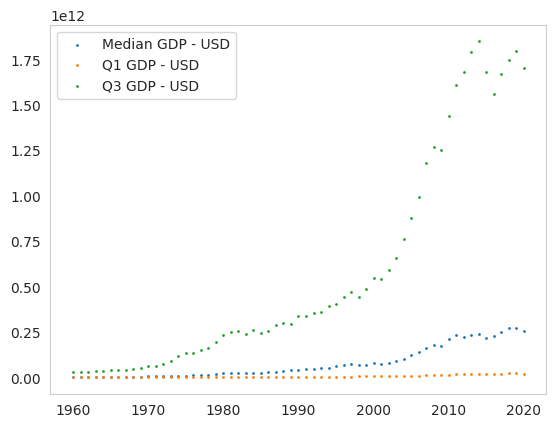

In [22]:
plt.scatter(stats['variable'],stats['50%'], s= 1, label='Median GDP - USD')
plt.scatter(stats['variable'],stats['25%'], s= 1, label='Q1 GDP - USD')
plt.scatter(stats['variable'],stats['75%'], s= 1, label='Q3 GDP - USD')
plt.legend()


In [23]:
fit = np.polyfit(stats['variable'], np.log(stats['50%']), 1,
                 w =np.sqrt(stats['50%']))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.07111806201145401
Coefficient B =  -117.09232591432259


count    6.100000e+01
mean     1.109316e+10
std      1.591221e+10
min      2.165587e+08
25%      2.494373e+09
50%      3.968645e+09
75%      1.374232e+10
max      8.677551e+10
Name: errors_model_50%, dtype: float64

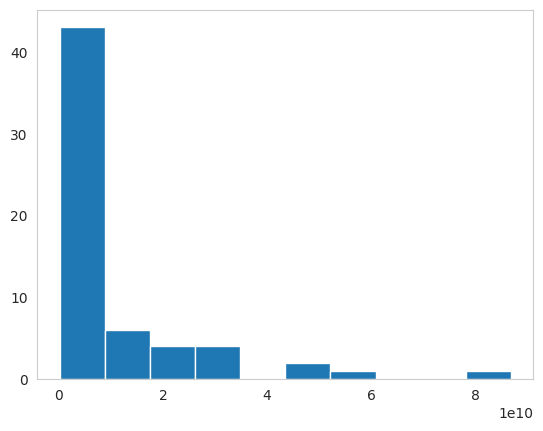

In [24]:
stats['model_50%'] = np.exp(fit[1]) * np.exp(fit[0] * stats['variable']) 
stats['errors_model_50%']  = np.abs(stats['50%'] - stats['model_50%'])
stats['errors_model_50%'].hist(grid=False)
stats['errors_model_50%'].describe()

In [25]:
fit = np.polyfit(stats['variable'], np.log(stats['75%']), 1,
                 w = np.sqrt(stats['75%']))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.0646318667262896
Coefficient B =  -102.0929023995858


count    6.100000e+01
mean     8.975987e+10
std      1.171396e+11
min      3.714321e+08
25%      1.831220e+10
50%      3.356206e+10
75%      1.093801e+11
max      5.964380e+11
Name: errors_model_75%, dtype: float64

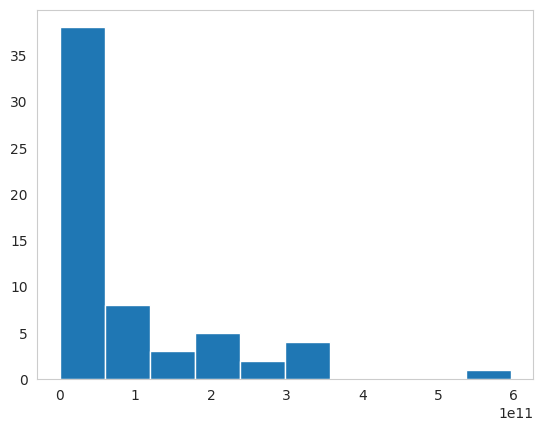

In [26]:
stats['model_75%'] = np.exp(fit[1]) * np.exp(fit[0] * stats['variable']) 
stats['errors_model_75%']  = np.abs(stats['75%'] - stats['model_75%'])
stats['errors_model_75%'].hist(grid=False)
stats['errors_model_75%'].describe()

In [27]:
fit = np.polyfit(stats['variable'], np.log(stats['25%']), 1,
                 w = np.sqrt(stats['25%']))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.06031305728310042
Coefficient B =  -97.86712787332907


count    6.100000e+01
mean     7.988075e+08
std      8.209953e+08
min      3.983350e+07
25%      3.445744e+08
50%      5.018512e+08
75%      8.281231e+08
max      5.059890e+09
Name: errors_model_25%, dtype: float64

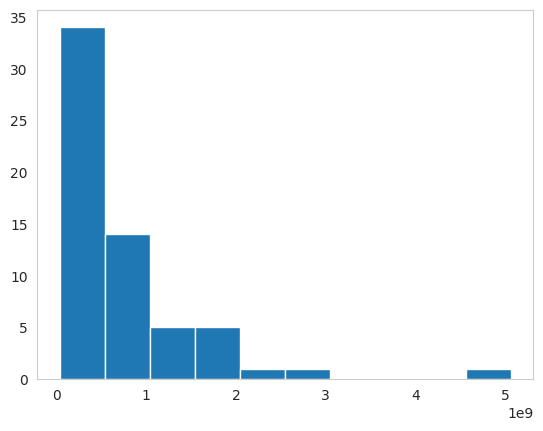

In [28]:
stats['model_25%'] = np.exp(fit[1]) * np.exp(fit[0] * stats['variable']) 
stats['errors_model_25%']  = np.abs(stats['25%'] - stats['model_25%'])
stats['errors_model_25%'].hist(grid=False)
stats['errors_model_25%'].describe()

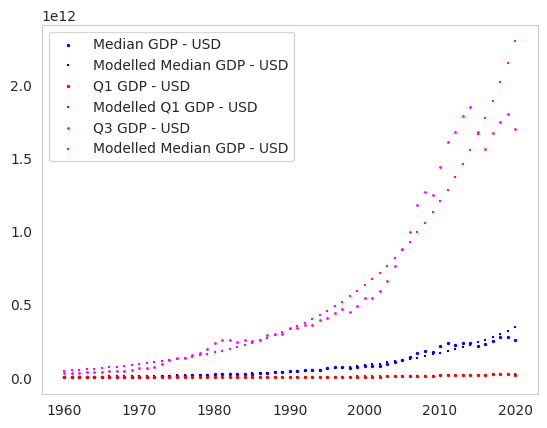

In [29]:
plt.scatter(stats['variable'],stats['50%'], s= 2, c = 'b', label='Median GDP - USD')
plt.scatter(stats['variable'],stats['model_50%'], s= 1, c ='b', marker = "+", label='Modelled Median GDP - USD')

plt.scatter(stats['variable'],stats['25%'], s= 2, c='r', label='Q1 GDP - USD')
plt.scatter(stats['variable'],stats['model_25%'], s= 1, c ='r', marker = "+", label='Modelled Q1 GDP - USD')

plt.scatter(stats['variable'],stats['75%'], s= 1, c= 'magenta', label='Q3 GDP - USD')
plt.scatter(stats['variable'],stats['model_75%'], s= 1, c ='magenta', marker = "+", label='Modelled Median GDP - USD')

plt.legend()


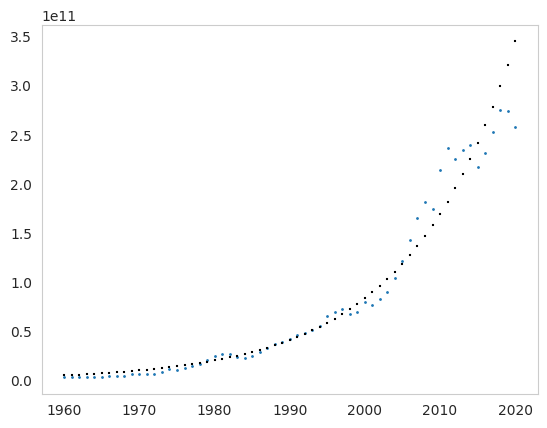

In [30]:
plt.scatter(stats['variable'],stats['50%'], s= 1)
plt.scatter(stats['variable'],stats['model_50%'], c='black', s = 1, marker = '+')

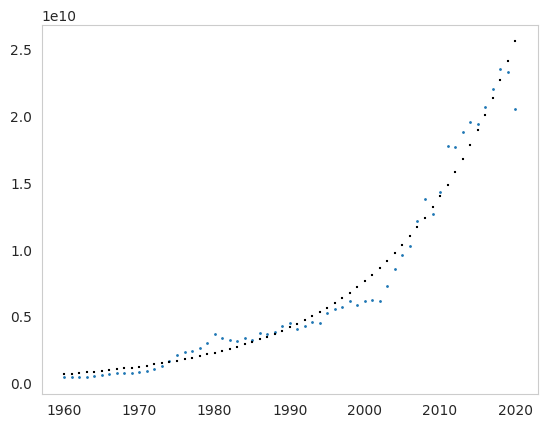

In [31]:
plt.scatter(stats['variable'],stats['25%'], s= 1)
plt.scatter(stats['variable'],stats['model_25%'], c='black', s = 1, marker = '+')

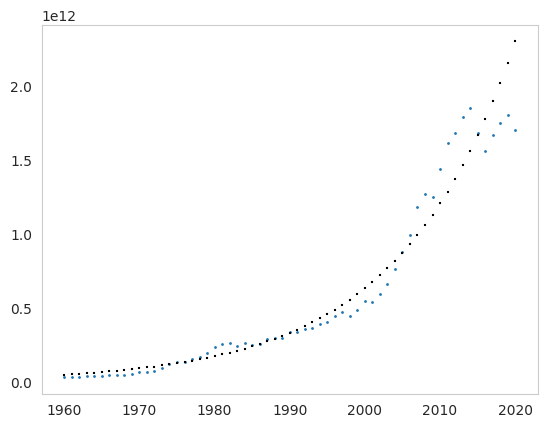

In [32]:
plt.scatter(stats['variable'],stats['75%'], s= 1)
plt.scatter(stats['variable'],stats['model_75%'], c='black', s = 1, marker = '+')

# World population

We discover again the population per country has some great variation. The median population per country appears to exponentially.

In [33]:
file = '/kaggle/input/world-population-dataset/world_population.csv'
pop = pd.read_csv(file)
print(pop.shape)
print(pop.dtypes)

(234, 17)
Rank                             int64
CCA3                            object
Country/Territory               object
Capital                         object
Continent                       object
2022 Population                  int64
2020 Population                  int64
2015 Population                  int64
2010 Population                  int64
2000 Population                  int64
1990 Population                  int64
1980 Population                  int64
1970 Population                  int64
Area (km²)                       int64
Density (per km²)              float64
Growth Rate                    float64
World Population Percentage    float64
dtype: object


In [34]:
pop.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


In [35]:
pop.columns

Index(['Rank', 'CCA3', 'Country/Territory', 'Capital', 'Continent',
       '2022 Population', '2020 Population', '2015 Population',
       '2010 Population', '2000 Population', '1990 Population',
       '1980 Population', '1970 Population', 'Area (km²)', 'Density (per km²)',
       'Growth Rate', 'World Population Percentage'],
      dtype='object')

<Axes: >

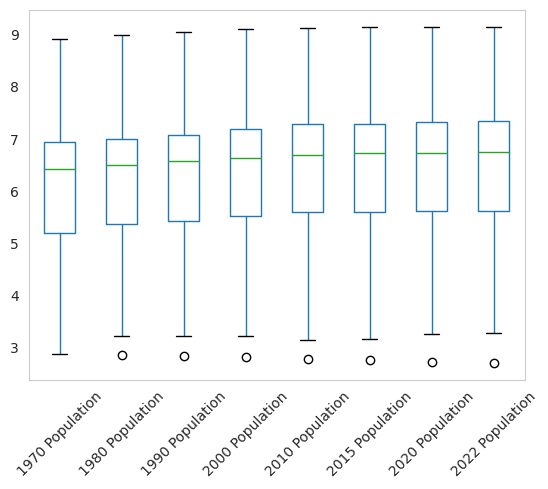

In [36]:
cols = ['1970 Population', '1980 Population', 
        '1990 Population','2000 Population',
        '2010 Population','2015 Population',
        '2020 Population','2022 Population']
temp = pop.loc[:, cols].copy(deep = True)
temp = np.log10(temp)
temp.boxplot(grid = False, rot =45)

In [37]:
years_label =['2022 Population', 
              '2020 Population', 
              '2015 Population',
              '2010 Population', 
              '2000 Population', 
              '1990 Population',
              '1980 Population', 
              '1970 Population']

id_vars = ['Rank', 'CCA3', 'Country/Territory', 
           'Capital', 'Continent', 'Area (km²)']
pop_long = pop.melt(id_vars = id_vars, value_vars = years_label)
pop_long.dtypes

Rank                  int64
CCA3                 object
Country/Territory    object
Capital              object
Continent            object
Area (km²)            int64
variable             object
value                 int64
dtype: object

In [38]:
pop_long.head()

,Rank,CCA3,Country/Territory,Capital,Continent,Area (km²),variable,value
0,36,AFG,Afghanistan,Kabul,Asia,652230,2022 Population,41128771
1,138,ALB,Albania,Tirana,Europe,28748,2022 Population,2842321
2,34,DZA,Algeria,Algiers,Africa,2381741,2022 Population,44903225
3,213,ASM,American Samoa,Pago Pago,Oceania,199,2022 Population,44273
4,203,AND,Andorra,Andorra la Vella,Europe,468,2022 Population,79824


In [39]:
len(pop_long['Country/Territory'].unique())

234

In [40]:
current = ['2022 Population', 
           '2020 Population', 
           '2015 Population',
           '2010 Population', 
           '2000 Population', 
           '1990 Population',
           '1980 Population', 
           '1970 Population']

new = [2022, 2020,2015,2010,2000,1990,1980,1970]

pop_long = pop_long.replace(current, new)
pop_long.head()

/tmp/ipykernel_33/2926351034.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pop_long = pop_long.replace(current, new)


,Rank,CCA3,Country/Territory,Capital,Continent,Area (km²),variable,value
0,36,AFG,Afghanistan,Kabul,Asia,652230,2022,41128771
1,138,ALB,Albania,Tirana,Europe,28748,2022,2842321
2,34,DZA,Algeria,Algiers,Africa,2381741,2022,44903225
3,213,ASM,American Samoa,Pago Pago,Oceania,199,2022,44273
4,203,AND,Andorra,Andorra la Vella,Europe,468,2022,79824


In [41]:
pop_long.dtypes

Rank                  int64
CCA3                 object
Country/Territory    object
Capital              object
Continent            object
Area (km²)            int64
variable              int64
value                 int64
dtype: object

In [42]:
pop_long['Area_log_10'] = np.log10(pop_long['Area (km²)'])
pop_long['value_log_10'] = np.log10(pop_long['value'])
pop_long.head()

,Rank,CCA3,Country/Territory,Capital,Continent,Area (km²),variable,value,Area_log_10,value_log_10
0,36,AFG,Afghanistan,Kabul,Asia,652230,2022,41128771,5.814401,7.614146
1,138,ALB,Albania,Tirana,Europe,28748,2022,2842321,4.458608,6.453673
2,34,DZA,Algeria,Algiers,Africa,2381741,2022,44903225,6.376895,7.652278
3,213,ASM,American Samoa,Pago Pago,Oceania,199,2022,44273,2.298853,4.646139
4,203,AND,Andorra,Andorra la Vella,Europe,468,2022,79824,2.670246,4.902133


In [43]:
pop.head()

,Rank,CCA3,Country/Territory,Capital,Continent,2022 Population,2020 Population,2015 Population,2010 Population,2000 Population,1990 Population,1980 Population,1970 Population,Area (km²),Density (per km²),Growth Rate,World Population Percentage
0,36,AFG,Afghanistan,Kabul,Asia,41128771,38972230,33753499,28189672,19542982,10694796,12486631,10752971,652230,63.0587,1.0257,0.52
1,138,ALB,Albania,Tirana,Europe,2842321,2866849,2882481,2913399,3182021,3295066,2941651,2324731,28748,98.8702,0.9957,0.04
2,34,DZA,Algeria,Algiers,Africa,44903225,43451666,39543154,35856344,30774621,25518074,18739378,13795915,2381741,18.8531,1.0164,0.56
3,213,ASM,American Samoa,Pago Pago,Oceania,44273,46189,51368,54849,58230,47818,32886,27075,199,222.4774,0.9831,0.00
4,203,AND,Andorra,Andorra la Vella,Europe,79824,77700,71746,71519,66097,53569,35611,19860,468,170.5641,1.0100,0.00


Text(0, 0.5, 'Population')

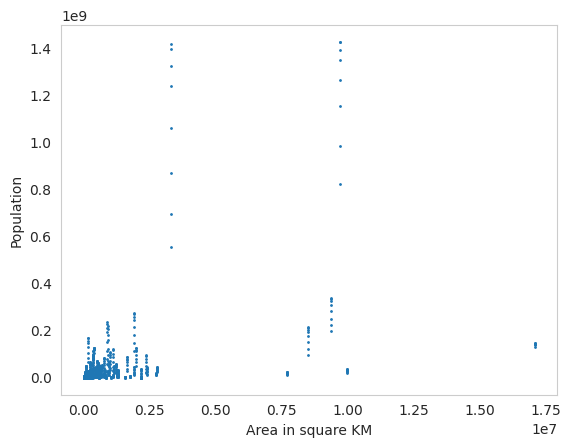

In [44]:
plt.scatter(pop_long['Area (km²)'],pop_long['value'], s=1)
plt.xlabel('Area in square KM')
plt.ylabel('Population')


Text(0, 0.5, 'Population (log scale)')

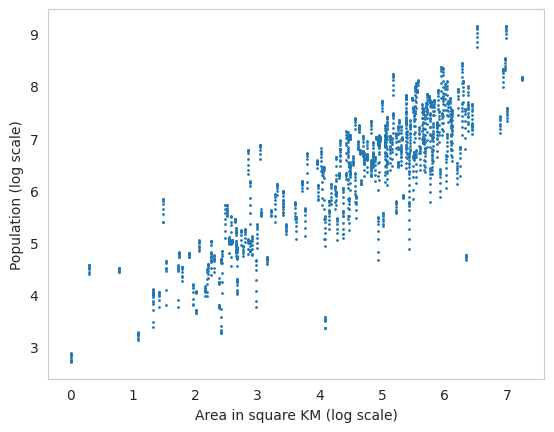

In [45]:
plt.scatter(pop_long['Area_log_10'],
            pop_long['value_log_10'], s=1)
plt.xlabel('Area in square KM (log scale)')
plt.ylabel('Population (log scale)')




In [46]:
pop_long.groupby(['CCA3']).describe()['value']

,count,mean,std,min,25%,50%,75%,max
CCA3,,,,,,,,
ABW,8.0,8.672675e+04,2.099067e+04,59106.0,64850.75,94721.0,104804.00,106585.0
AFG,8.0,2.444019e+07,1.272585e+07,10694796.0,12053216.00,23866327.0,35058181.75,41128771.0
AGO,8.0,2.038648e+07,1.140585e+07,6029700.0,10953990.25,19879123.5,29452912.00,35588987.0
AIA,8.0,1.141812e+04,3.955593e+03,6283.0,7877.00,12109.5,14790.00,15857.0
ALB,8.0,2.906065e+06,2.860820e+05,2324731.0,2860717.00,2897940.0,3001743.50,3295066.0
...,...,...,...,...,...,...,...,...
WSM,8.0,1.869280e+05,2.718362e+04,142771.0,167365.75,189340.0,206410.50,222382.0
YEM,8.0,2.091169e+07,1.043535e+07,6843607.0,12332575.25,21686323.0,29458420.25,33696614.0
ZAF,8.0,4.560999e+07,1.392213e+07,22368306.0,37274064.75,49299093.5,56607859.75,59893885.0


In [47]:
fit = np.polyfit(pop_long['Area_log_10'], np.log(pop_long.value_log_10), 1,
                 w = np.sqrt(pop_long['Area_log_10']))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])




Coefficient A  =  0.11403525470531985
Coefficient B =  1.3153462719013784


count    61.000000
mean      1.771376
std       0.424304
min       1.277968
25%       1.425505
50%       1.665613
75%       1.960580
max       2.807485
Name: errors_model_a, dtype: float64

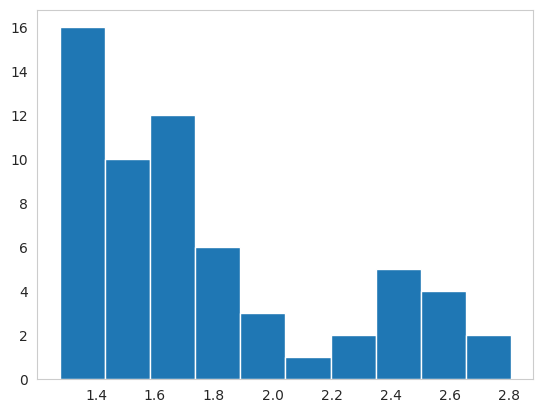

In [48]:
pop_long['model_a'] = np.exp(fit[1]) * np.exp(fit[0] * pop_long['Area_log_10']) 
stats['errors_model_a']  = np.abs(pop_long['Area_log_10'] - pop_long['model_a'])
stats['errors_model_a'].hist(grid=False)
stats['errors_model_a'].describe()

In [49]:
# gaussian mixture clustering
from sklearn.mixture import GaussianMixture as GMM
from matplotlib import pyplot
from sklearn import metrics
# define dataset
X = np.array(pop_long['Area_log_10']).reshape(-1,1)
y = np.array(pop_long['value_log_10']).reshape(-1,1)

print('X \n' , X)
print('y \n', y)

X 
 [[5.81440077]
 [4.45860764]
 [6.37689453]
 ...
 [5.7226076 ]
 [5.87657114]
 [5.59190677]]
y 
 [[7.61414573]
 [6.45367312]
 [7.65227753]
 ...
 [6.83528506]
 [6.63161329]
 [6.71624698]]


In [50]:
def SelBest(arr:list, X:int)->list:
    '''
    returns the set of X configurations with shorter distance
    '''
    dx=np.argsort(arr)[:X]
    return arr[dx]

An early investigation suggested a high level of clusterisation may be suitable. Therefore, we start from 100 to 230, to lower time and computations resources.

n_cluster :  100 mean_bic :  3856.636008099107 std_bic :  55.47173557029389
n_cluster :  110 mean_bic :  3565.0920937256656 std_bic :  51.752097688005044
n_cluster :  120 mean_bic :  3238.5537606329126 std_bic :  50.77634947393244
n_cluster :  130 mean_bic :  2970.963428753665 std_bic :  29.957044359627815
n_cluster :  140 mean_bic :  2718.7738015616546 std_bic :  36.56849723532222
n_cluster :  150 mean_bic :  2461.7434436986937 std_bic :  28.967210977215455
n_cluster :  160 mean_bic :  2270.44758783618 std_bic :  20.198361504024515
n_cluster :  170 mean_bic :  2145.6805203386057 std_bic :  12.24340901736794
n_cluster :  180 mean_bic :  2077.753389432272 std_bic :  7.143630339477631
n_cluster :  190 mean_bic :  2103.315153452777 std_bic :  5.4441102760476765
n_cluster :  200 mean_bic :  2201.952212797958 std_bic :  1.697177350126278
n_cluster :  210 mean_bic :  2420.0825722867294 std_bic :  3.6913212538211284e-05
n_cluster :  220 mean_bic :  2646.1275722457517 std_bic :  0.000310226759

Text(0, 0.5, 'Score')

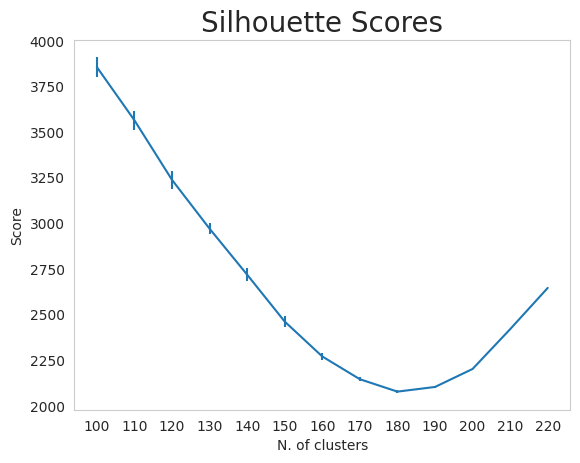

In [51]:
n_clusters=np.arange(100,230 , 10)
bic=[]
bics_err=[]
iterations=20
for n in n_clusters:
    tmp_bic=[]
    for _ in range(iterations):
        gmm=GMM(n, n_init=2).fit(X,y) 
        labels=gmm.predict(X)
        tmp_bic.append(gmm.bic(X))   
    val=np.mean(SelBest(np.array(tmp_bic), int(iterations)))
    err=np.std(tmp_bic)
    bic.append(val)
    bics_err.append(err)
    print('n_cluster : ' , n , 'mean_bic : ', val, 'std_bic : ', err)
    
plt.errorbar(n_clusters, bic, yerr=bics_err)
plt.title("Silhouette Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")

n_cluster :  180 mean_bic :  2077.3715072718583 std_bic :  6.009613137236369
n_cluster :  181 mean_bic :  2074.610155198689 std_bic :  6.132013300665143
n_cluster :  182 mean_bic :  2076.9811505087523 std_bic :  7.742041551849214
n_cluster :  183 mean_bic :  2072.006716491217 std_bic :  4.6829381188961
n_cluster :  184 mean_bic :  2075.581410104163 std_bic :  4.8345628408635255
n_cluster :  185 mean_bic :  2078.718600132686 std_bic :  5.410150134557857
n_cluster :  186 mean_bic :  2082.679191338651 std_bic :  4.369518481868247
n_cluster :  187 mean_bic :  2086.374873318467 std_bic :  4.443574187828375
n_cluster :  188 mean_bic :  2091.777437198426 std_bic :  5.27966678892769
n_cluster :  189 mean_bic :  2097.306969274856 std_bic :  4.407326580151155
n_cluster :  190 mean_bic :  2101.285361999117 std_bic :  4.428161881020638
n_cluster :  191 mean_bic :  2109.4111420235167 std_bic :  3.964093365119614
n_cluster :  192 mean_bic :  2114.2438137323797 std_bic :  3.0248979834840086
n_cluster

Text(0, 0.5, 'Score')

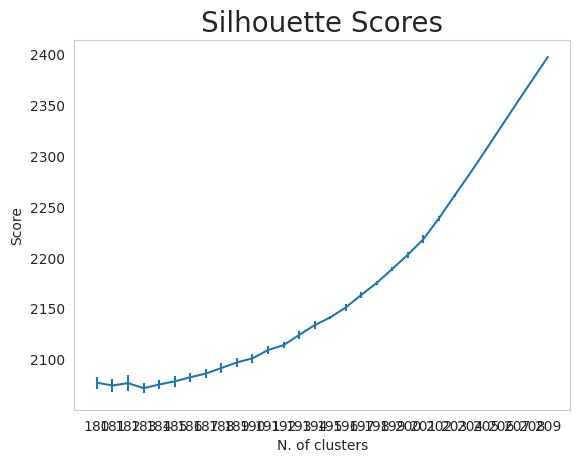

In [52]:
n_clusters=np.arange(180,200)
bic=[]
bics_err=[]
iterations=20
for n in n_clusters:
    tmp_bic=[]
    for _ in range(iterations):
        gmm=GMM(n, n_init=2).fit(X,y) 
        labels=gmm.predict(X)
        tmp_bic.append(gmm.bic(X))   
    val=np.mean(SelBest(np.array(tmp_bic), int(iterations)))
    err=np.std(tmp_bic)
    bic.append(val)
    bics_err.append(err)
    print('n_cluster : ' , n , 'mean_bic : ', val, 'std_bic : ', err)
    
plt.errorbar(n_clusters, bic, yerr=bics_err)
plt.title("Silhouette Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")

The minimum and optimum number of clusters may vary each run. It is unknown whether it is a global or local optimum. However, it has been approximately around  180 more than 31 times.

array([ 54, 122,  76, ..., 120, 110, 135])

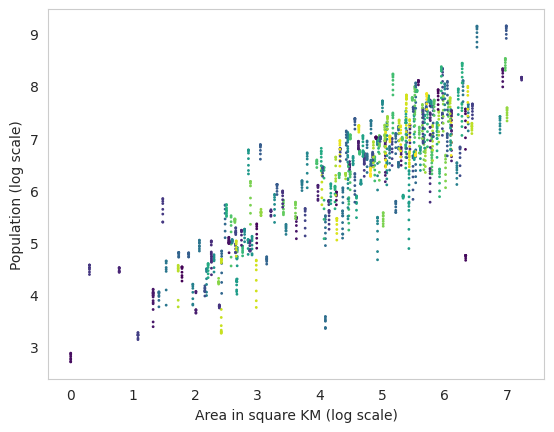

In [53]:
from sklearn.mixture import GaussianMixture 
gmm = GaussianMixture(n_components=180)
gmm.fit(X)
labels = gmm.predict(X)
probs = gmm.predict_proba(X)

plt.scatter(X, y, c=labels, s=1, cmap='viridis',)
plt.xlabel('Area in square KM (log scale)')
plt.ylabel('Population (log scale)')
labels


Earlier we have discovered there are 234 countries. The number of components is quite close from the number of unique territories. The yearly observations made for each country may lead to a cluster for each country. However, some countries may have similar population and areas and form a cluster.  

We propose to use instead the expected population through time to try to overcome this observation. We use the median point.

In [54]:
pop_long.dtypes

Rank                   int64
CCA3                  object
Country/Territory     object
Capital               object
Continent             object
Area (km²)             int64
variable               int64
value                  int64
Area_log_10          float64
value_log_10         float64
model_a              float64
dtype: object

In [55]:
means = pop_long.loc[: , ['CCA3','Area (km²)','value']].copy(deep = True)
means.describe()


,Area (km²),value
count,1.872000e+03,1.872000e+03
mean,5.814494e+05,2.661274e+07
std,1.758542e+06,1.133600e+08
min,1.000000e+00,5.100000e+02
25%,2.586000e+03,3.180410e+05
50%,8.119950e+04,4.225097e+06
75%,4.383170e+05,1.546753e+07
max,1.709824e+07,1.425887e+09


In [56]:
tmp = means.groupby(['CCA3','Area (km²)']).median().reset_index()
tmp

,CCA3,Area (km²),value
0,ABW,180,94721.0
1,AFG,652230,23866327.0
2,AGO,1246700,19879123.5
3,AIA,91,12109.5
4,ALB,28748,2897940.0
...,...,...,...
229,WSM,2842,189340.0
230,YEM,527968,21686323.0
231,ZAF,1221037,49299093.5
232,ZMB,752612,11841611.0


X 
 234
y 
 234


Text(0, 0.5, 'Population (log scale)')

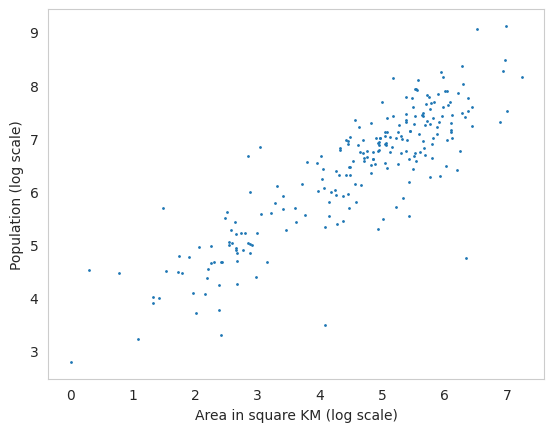

In [57]:
# gaussian mixture clustering
from sklearn.mixture import GaussianMixture as GMM
from matplotlib import pyplot
from sklearn import metrics
# define dataset
X = np.array(np.log10(tmp['Area (km²)'])).reshape(-1,1)
y = np.array(np.log10(tmp['value'])).reshape(-1,1)

print('X \n' , len(X))
print('y \n', len(y))
plt.scatter(X,
            y, s=1)
plt.xlabel('Area in square KM (log scale)')
plt.ylabel('Population (log scale)')

We reduced the number of dimension from three to two - we removed the temporal dimension. We now discover with the log scale that an exponential tend may exist. 

A Gaussian mixture model appears not to fit properly. A regression has demonstrated that a exponential equation is likely to model the relationship between the size of a country and an expected population. The exponential equation suggests the size of the territories are likely to impact on the population residing in the country. Other factors such as geographical features, for example, should be considered. This suggestion is not exhaustive. 


n_cluster :  2 mean_bic :  810.7546783544826 std_bic :  1.1368683772161603e-13
n_cluster :  3 mean_bic :  826.0248752749292 std_bic :  0.04386275255791023
n_cluster :  4 mean_bic :  836.9482665520421 std_bic :  2.4987458886256007
n_cluster :  5 mean_bic :  851.1583710650709 std_bic :  0.3326180440302201
n_cluster :  6 mean_bic :  864.5621764585967 std_bic :  2.986333140880444
n_cluster :  7 mean_bic :  877.8200894841821 std_bic :  3.4934227400776683
n_cluster :  8 mean_bic :  889.3653062190849 std_bic :  3.624720032953729
n_cluster :  9 mean_bic :  900.9320916437897 std_bic :  1.271264802422914


Text(0, 0.5, 'Score')

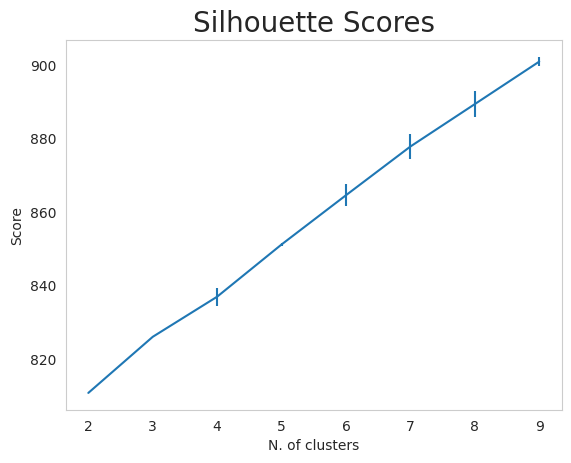

In [58]:
n_clusters=np.arange(2,10,1)
bic=[]
bics_err=[]
iterations=20
for n in n_clusters:
    tmp_bic=[]
    for _ in range(iterations):
        gmm=GMM(n, n_init=2).fit(X,y) 
        labels=gmm.predict(X)
        tmp_bic.append(gmm.bic(X))   
    val=np.mean(SelBest(np.array(tmp_bic), int(iterations)))
    err=np.std(tmp_bic)
    bic.append(val)
    bics_err.append(err)
    print('n_cluster : ' , n , 'mean_bic : ', val, 'std_bic : ', err)
    
plt.errorbar(n_clusters, bic, yerr=bics_err)
plt.title("Silhouette Scores", fontsize=20)
plt.xticks(n_clusters)
plt.xlabel("N. of clusters")
plt.ylabel("Score")

Text(0, 0.5, 'Population (log scale)')

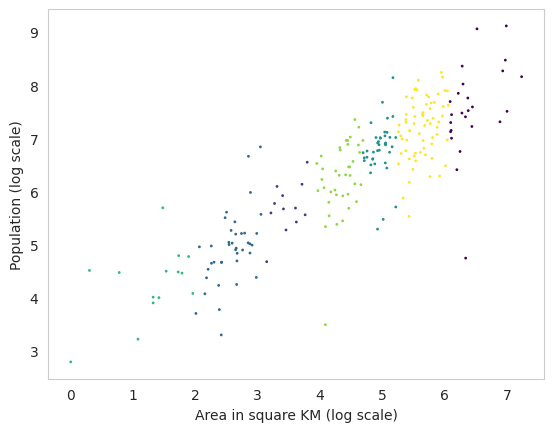

In [59]:
from sklearn.mixture import GaussianMixture 
gmm = GaussianMixture(n_components=7)
gmm.fit(X)
labels = gmm.predict(X)
probs = gmm.predict_proba(X)

plt.scatter(X, y, c=labels, s=1, cmap='viridis',)
plt.xlabel('Area in square KM (log scale)')
plt.ylabel('Population (log scale)')
#labels


In [60]:

fit = np.polyfit(np.log10(tmp['Area (km²)']), 
                 np.log10(tmp['value']), 1,
                 w = np.sqrt(np.log10(tmp['Area (km²)'])))

#view the output of the model
print('Coefficient A  = ', fit[0])
print('Coefficient B = ', fit[1])



Coefficient A  =  0.6973094427440153
Coefficient B =  3.233127897973355


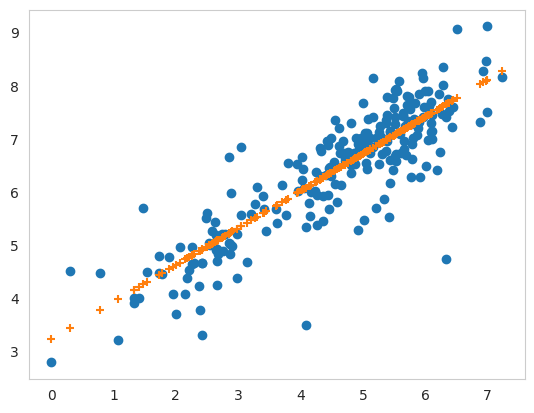

In [61]:
import matplotlib.pyplot as plt
tmp['model'] = fit[1] +  fit[0] * np.log10(tmp['Area (km²)'])


plt.scatter(x=np.log10(tmp['Area (km²)']), y= np.log10(tmp['value']), label = 'Area in square km')
plt.scatter(x=np.log10(tmp['Area (km²)']), y= tmp['model'], marker = "+")



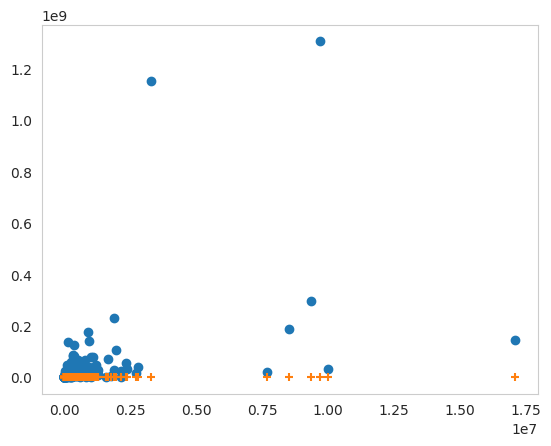

In [62]:
import matplotlib.pyplot as plt
tmp['model'] = np.exp(fit[1]) * np.exp(fit[0] * np.log10(tmp['Area (km²)'])) 


plt.scatter(x=tmp['Area (km²)'], y= tmp['value'], label = 'Area in square km')
plt.scatter(x=tmp['Area (km²)'], y= tmp['model'], marker = "+")




count    2.340000e+02
mean     5.805673e+05
std      1.761308e+06
min      8.985719e-01
25%      2.374108e+03
50%      8.042166e+04
75%      4.291368e+05
max      1.709431e+07
Name: errors_model, dtype: float64

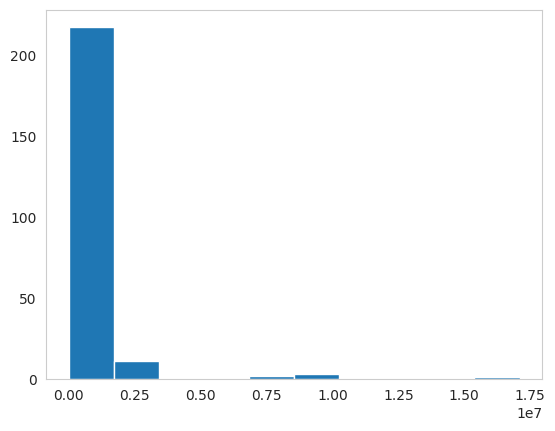

In [63]:
tmp['errors_model']  = np.abs(tmp['Area (km²)'] - tmp['model'])
tmp['errors_model'].hist(grid=False)
tmp['errors_model'].describe()

We explore next the population concentration in countries. We surmise the more individuals living closely, the global emissions may occur.  We will explore hot the population concentration has evolved between 1970 and 2022.

We are going find the population per km square - $pop_per_km_square =  value/ area in km square$.

In [64]:
pop_long.dtypes

Rank                   int64
CCA3                  object
Country/Territory     object
Capital               object
Continent             object
Area (km²)             int64
variable               int64
value                  int64
Area_log_10          float64
value_log_10         float64
model_a              float64
dtype: object

We population per country

In [65]:
pop_long['pop_per_km_square'] = pop_long.value/pop_long['Area (km²)']
pop_long.groupby(['CCA3']).describe()['pop_per_km_square']

,count,mean,std,min,25%,50%,75%,max
CCA3,,,,,,,,
ABW,8.0,481.815278,116.614859,328.366667,360.281944,526.227778,582.244444,592.138889
AFG,8.0,37.471742,19.511296,16.397277,18.480009,36.591888,53.751256,63.058692
AGO,8.0,16.352353,9.148836,4.836528,8.786388,15.945395,23.624699,28.546552
AIA,8.0,125.473901,43.468054,69.043956,86.560440,133.071429,162.527473,174.252747
ALB,8.0,101.087550,9.951370,80.865834,99.510122,100.804926,104.415733,114.618965
...,...,...,...,...,...,...,...,...
WSM,8.0,65.773399,9.564960,50.236101,58.890130,66.622097,72.628607,78.248417
YEM,8.0,39.607873,19.765118,12.962162,23.358566,41.075071,55.795844,63.823213
ZAF,8.0,37.353488,11.401890,18.319106,30.526565,40.374774,46.360479,49.051654


In [67]:
pop_long.dtypes

Rank                   int64
CCA3                  object
Country/Territory     object
Capital               object
Continent             object
Area (km²)             int64
variable               int64
value                  int64
Area_log_10          float64
value_log_10         float64
model_a              float64
pop_per_km_square    float64
dtype: object

In [68]:
pop_long.loc[pop_long['Area (km²)'] > pop_long['value'],:]

,Rank,CCA3,Country/Territory,Capital,Continent,Area (km²),variable,value,Area_log_10,value_log_10,model_a,pop_per_km_square
64,231,FLK,Falkland Islands,Stanley,South America,12173,2022,3780,4.085398,3.577492,5.937129,0.310523
78,208,GRL,Greenland,Nuuk,North America,2166086,2022,56466,6.335676,4.751787,7.673990,0.026068
298,231,FLK,Falkland Islands,Stanley,South America,12173,2020,3747,4.085398,3.573684,5.937129,0.307812
312,208,GRL,Greenland,Nuuk,North America,2166086,2020,56026,6.335676,4.748390,7.673990,0.025865
532,231,FLK,Falkland Islands,Stanley,South America,12173,2015,3408,4.085398,3.532500,5.937129,0.279964
546,208,GRL,Greenland,Nuuk,North America,2166086,2015,55895,6.335676,4.747373,7.673990,0.025805
766,231,FLK,Falkland Islands,Stanley,South America,12173,2010,3187,4.085398,3.503382,5.937129,0.261809
780,208,GRL,Greenland,Nuuk,North America,2166086,2010,56351,6.335676,4.750902,7.673990,0.026015
1000,231,FLK,Falkland Islands,Stanley,South America,12173,2000,3080,4.085398,3.488551,5.937129,0.253019
1014,208,GRL,Greenland,Nuuk,North America,2166086,2000,56184,6.335676,4.749613,7.673990,0.025938


In [69]:
rows = pop_long['Area (km²)'] > pop_long['value']
temp = pop_long.loc[rows,['CCA3','Country/Territory','Continent','variable']]
temp = temp.groupby(['CCA3','Country/Territory','Continent']).count().reset_index()
temp

,CCA3,Country/Territory,Continent,variable
0,ESH,Western Sahara,Africa,3
1,FLK,Falkland Islands,South America,8
2,GRL,Greenland,North America,8
3,GUF,French Guiana,South America,2
4,MNG,Mongolia,Asia,1
5,NAM,Namibia,Africa,1


In [70]:
pop.dtypes

Rank                             int64
CCA3                            object
Country/Territory               object
Capital                         object
Continent                       object
2022 Population                  int64
2020 Population                  int64
2015 Population                  int64
2010 Population                  int64
2000 Population                  int64
1990 Population                  int64
1980 Population                  int64
1970 Population                  int64
Area (km²)                       int64
Density (per km²)              float64
Growth Rate                    float64
World Population Percentage    float64
dtype: object

,1970,1980,1990,2000,2015,2020,2022
count,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000
mean,1.594789,1.682442,1.769069,1.834934,1.922655,1.946820,1.954727
std,0.784700,0.765499,0.754869,0.742757,0.729774,0.724947,0.723207
min,-1.678295,-1.635786,-1.590609,-1.586063,-1.588303,-1.587286,-1.583889
25%,1.120070,1.224847,1.313055,1.417633,1.529090,1.579103,1.584492
50%,1.629144,1.736050,1.850794,1.895206,1.965093,1.972973,1.979262
75%,2.098137,2.164787,2.230460,2.269495,2.356745,2.381238,2.378272
max,4.084040,4.131555,4.180828,4.210385,4.311923,4.353007,4.364969


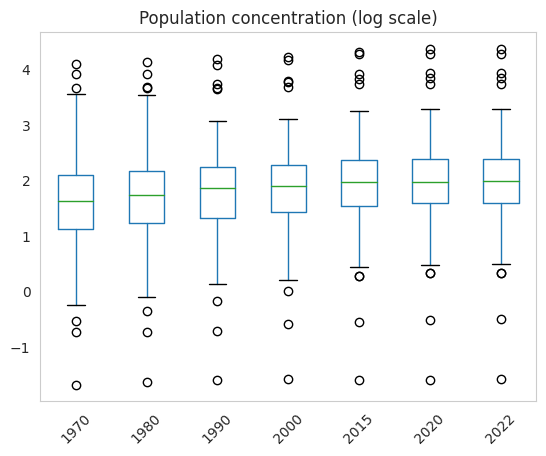

In [71]:
tmp = pd.DataFrame()
tmp['1970'] = np.log10(pop['1970 Population']/pop['Area (km²)'])
tmp['1980'] = np.log10(pop['1980 Population']/pop['Area (km²)'])
tmp['1990'] = np.log10(pop['1990 Population']/pop['Area (km²)'])
tmp['2000'] = np.log10(pop['2000 Population']/pop['Area (km²)'])
tmp['2015'] = np.log10(pop['2015 Population']/pop['Area (km²)'])
tmp['2020'] = np.log10(pop['2020 Population']/pop['Area (km²)'])
tmp['2022'] = np.log10(pop['2022 Population']/pop['Area (km²)'])
ax = tmp.boxplot(grid = False, rot =45)
plt.title('Population concentration (log scale)')
tmp.describe()


The median population concentration appears to increase through time. The number of outliers appears to both become smaller or larger.  It may indicates some countries may be becoming less populated while other increase. 

All the values are shown in log scale 10. A negative value suggests a very low density - the area in square km is greater than the population. We found five countries above. 